# 🛒 SmartCart Customer Segmentation System

**Objective:** Build an intelligent, unsupervised customer segmentation system for SmartCart — a growing e-commerce platform — by discovering hidden behavioural patterns across 2,240 customers and 22 attributes. The resulting clusters will power personalised marketing, targeted retention strategies, and early churn detection.

**Approach:** K-Means & Agglomerative Clustering on PCA-reduced features, validated via Elbow Method and Silhouette Analysis.

---
| Phase | Description |
|---|---|
| Data Preprocessing | Handle missing values, engineer new features |
| EDA | Outlier removal, correlation analysis |
| Encoding & Scaling | Prepare features for clustering |
| Dimensionality Reduction | PCA (3 components) |
| Cluster Optimisation | Elbow Method + Silhouette Analysis |
| Clustering | K-Means & Agglomerative Clustering |
| Cluster Profiling | Interpret and characterise each segment |

## 1. Library Imports

Importing core libraries for data manipulation, visualisation, and machine learning.

In [350]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load Dataset

Loading the SmartCart customer dataset containing **2,240 records** and **22 features** spanning demographics, purchase behaviour, channel activity, and customer feedback.

In [351]:
df = pd.read_csv('smartcart_customers.csv')

## 3. Exploratory Data Overview

A first look at the dataset - structure, shape, and feature types to understand what we are working with before any transformation.

In [352]:
df.head()
df.shape

(2240, 22)

### 3.1 Data Types & Missing Values

Checking column data types and identifying any null values that require treatment before modelling.

In [353]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## 4. Data Preprocessing

### 4.1 Handling Missing Values

The `Income` column contains missing entries. Since income is a numerical, right-skewed feature, we impute using the **median** - a robust measure that is less sensitive to outliers than the mean.

In [354]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [355]:
df.isnull().sum()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## 5. Feature Engineering

Constructing meaningful features from raw columns to better represent customer behaviour and demographics for the clustering model.

### 5.1 Customer Age

Deriving customer age from `Year_Birth` using the current reference year (2026). Age is a more interpretable demographic feature for segmentation than year of birth.

In [356]:
# age 
df['Age'] = 2026-df['Year_Birth']

In [357]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


### 5.2 Customer Tenure

Calculating the number of days since each customer enrolled with SmartCart. Longer tenure can signal loyalty or stagnation and is valuable for distinguishing customer lifecycle stages.

In [358]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

reference_date = df['Dt_Customer'].max()

df['Customer_Tenure_Days'] = (reference_date - df['Dt_Customer']).dt.days
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


### 5.3 Total Spending

Aggregating spend across all product categories (`Wines`, `Fruits`, `Meat`, `Fish`, `Sweets`, `Gold`) into a single composite feature - `Total_Spendings` - that captures overall purchasing power.

In [359]:
spending_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spendings'] = df[spending_columns].sum(axis=1)

### 5.4 Total Household Children

Combining `Kidhome` (young children) and `Teenhome` (teenagers) into `Total_Children`. Family size is a known driver of shopping behaviour and spending priorities.

In [360]:
df['Total_Children'] = df['Kidhome'] + df['Teenhome']
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spendings,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


### 5.5 Education Level Simplification

Consolidating the five original education categories into three interpretable tiers:

| Original | Mapped To |
|---|---|
| Basic, 2n Cycle | Undergraduate |
| Graduation | Graduate |
| Master, PhD | Postgraduate |

This reduces noise and prevents the encoder from creating too many sparse binary columns.

In [361]:
df['Education'] = df['Education'].replace(
  {'Basic': 'Undergraduate', '2n Cycle': 'Undergraduate',
  'Graduation': 'Graduate',
  'Master': 'Postgraduate', 'PhD': 'Postgraduate'})
df['Education'].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

### 5.6 Living Situation

Simplifying `Marital_Status` into a binary `Living_With` feature reflecting whether a customer lives with a partner or alone. Ambiguous entries (`Absurd`, `YOLO`) are treated as living alone.

| Original | Mapped To |
|---|---|
| Married, Together | Partner |
| Single, Divorced, Widow, Absurd, YOLO | Alone |

In [362]:
df['Living_With'] = df['Marital_Status'].replace(
  {'Married': 'Partner', 'Together': 'Partner',
  'Single': 'Alone',
  'Divorced': 'Alone', 'Widow': 'Alone', 'Absurd': 'Alone', 'YOLO': 'Alone'})

df['Living_With'].value_counts()  


Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [363]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spendings,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


## 6. Column Reduction

Dropping raw columns that have either been replaced by engineered features or are not relevant to unsupervised modelling:

- **Identifiers:** `ID`
- **Replaced by engineered features:** `Year_Birth`, `Dt_Customer`, `Kidhome`, `Teenhome`, `Marital_Status`
- **Replaced by `Total_Spendings`:** all individual `Mnt*` columns

In [364]:
cols = ['ID', 'Year_Birth', 'Dt_Customer', 'Kidhome', 'Teenhome', 'Marital_Status']
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [365]:
df_cleaned.shape

(2240, 15)

In [366]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spendings,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## 7. Outlier Detection & Removal

Visualising key numerical features via a pairplot to identify extreme values that could distort cluster boundaries.

Identified outliers:
- **Age > 90:** Likely data entry errors (e.g., birth year in 1800s)
- **Income > 600,000:** Extreme outlier far beyond the realistic income range of the customer base

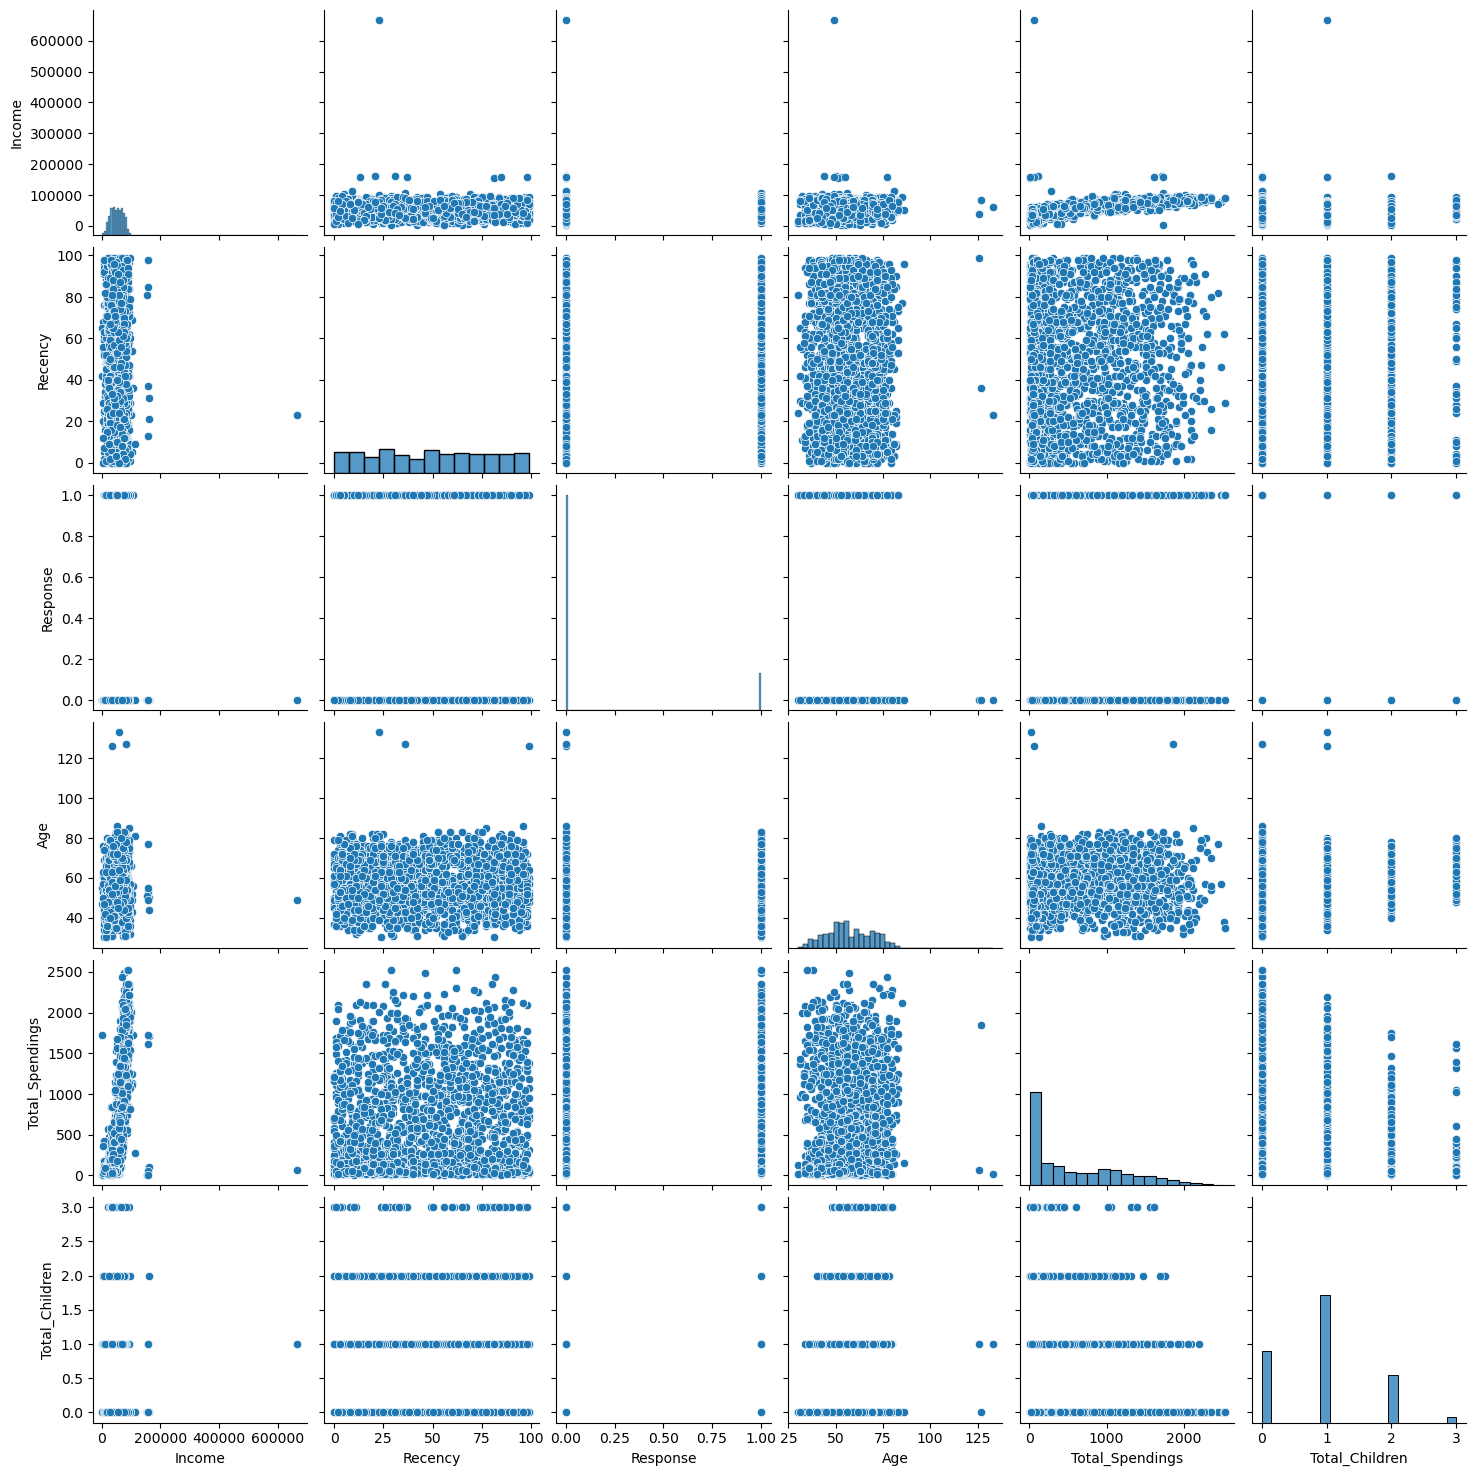

In [367]:
cols = ['Income', 'Recency', 'Response', 'Age', 'Total_Spendings', 'Total_Children']

sns.pairplot(df_cleaned[cols])
plt.show()

In [368]:
print(" Data size before removing outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned['Age'] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned['Income'] < 600000) ]

print(" Data size after removing outliers:", len(df_cleaned))

 Data size before removing outliers: 2240
 Data size after removing outliers: 2236


## 8. Correlation Analysis

A heatmap of Pearson correlation coefficients reveals linear relationships between features. Highly correlated features may add redundancy, while near-zero correlations flag features providing independent signal. This also informs feature importance before encoding and scaling.

In [369]:
corr = df_cleaned.corr(numeric_only=True)

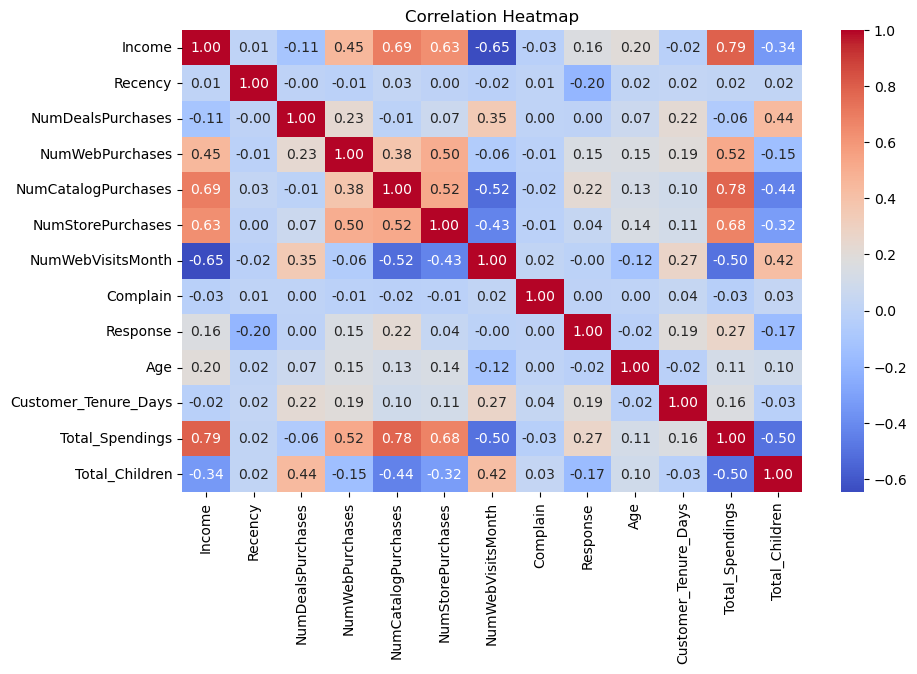

In [370]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## 9. Categorical Encoding

Applying **One-Hot Encoding** to the two remaining categorical features - `Education` and `Living_With` - to convert them into numerical binary columns compatible with the distance-based clustering algorithms.

In [371]:
from sklearn.preprocessing import OneHotEncoder

In [372]:
ohe = OneHotEncoder()
categorical_cols = ['Education', 'Living_With']
encoded_data = ohe.fit_transform(df_cleaned[categorical_cols])

df_encoded = pd.DataFrame(encoded_data.toarray(), columns = ohe.get_feature_names_out(categorical_cols))


In [373]:
df_encoded = pd.concat([df_cleaned.drop(columns=categorical_cols).reset_index(drop=True), df_encoded.reset_index(drop=True)], axis=1)

In [374]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spendings,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [375]:
df_encoded.shape

(2236, 18)

## 10. Feature Scaling

Applying **StandardScaler** (zero mean, unit variance) to all features. This step is critical for K-Means and Agglomerative Clustering, which are sensitive to the magnitude and scale of features - without scaling, high-range features like `Income` would dominate the distance calculations.

In [376]:
from sklearn.preprocessing import StandardScaler


In [377]:
X = df_encoded

In [378]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 11. Dimensionality Reduction — PCA

Applying **Principal Component Analysis (PCA)** to compress the high-dimensional feature space into **3 principal components**, capturing the maximum variance while enabling 3D visualisation. This also helps reduce noise and speeds up clustering.

The 3D scatter plot below shows the natural distribution of customers in the reduced PCA space before any cluster labels are applied.

In [379]:
from sklearn.decomposition import PCA

In [380]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

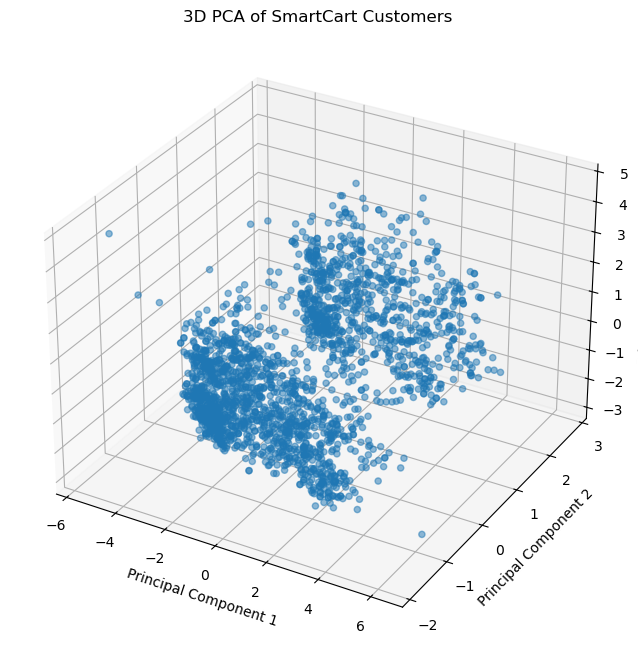

In [381]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], alpha=0.5)
ax.set_xlabel('Principal Component 1') 
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA of SmartCart Customers')
plt.show()


## 12. Optimal Cluster Count Selection

Determining the ideal number of clusters `k` using two complementary validation techniques to avoid arbitrary selection.

### 12.1 Elbow Method

Plotting the **Within-Cluster Sum of Squares (WCSS)** across `k = 1` to `10`. The optimal `k` is identified at the "elbow" — the point where adding more clusters yields diminishing returns in variance reduction.

The `KneeLocator` library is used to programmatically pinpoint the elbow.

In [382]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters = k, random_state=42)
  kmeans.fit_predict(X_pca)
  wcss.append(kmeans.inertia_)


In [383]:
from kneed import KneeLocator

knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
optimal_k = knee.knee
print(f"Optimal number of clusters: {optimal_k}")

Optimal number of clusters: 4


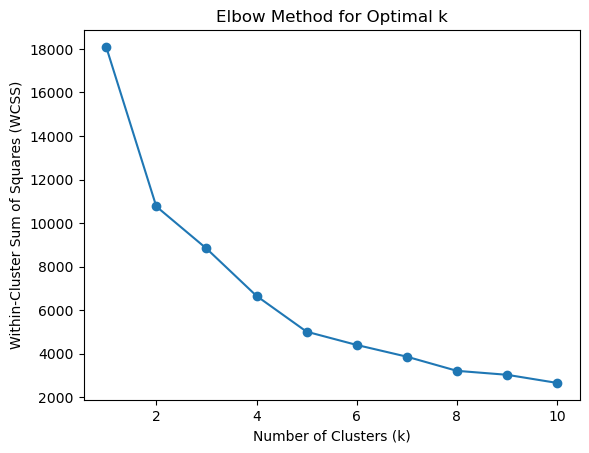

In [384]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.show()

### 12.2 Silhouette Analysis

The **Silhouette Score** measures how similar each customer is to its own cluster compared to other clusters. Scores range from -1 to +1 — higher values indicate well-separated, compact clusters.

This serves as an independent cross-check against the Elbow Method.

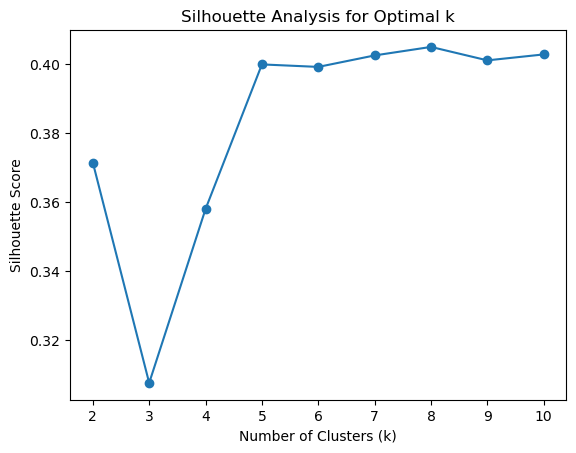

In [385]:
from sklearn.metrics import silhouette_score

score = []
for k in range(2, 11):
  kmeans = KMeans(n_clusters = k, random_state=42)
  labels = kmeans.fit_predict(X_pca)
  score.append(silhouette_score(X_pca, labels))

plt.plot(range(2, 11), score, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal k')
plt.show()

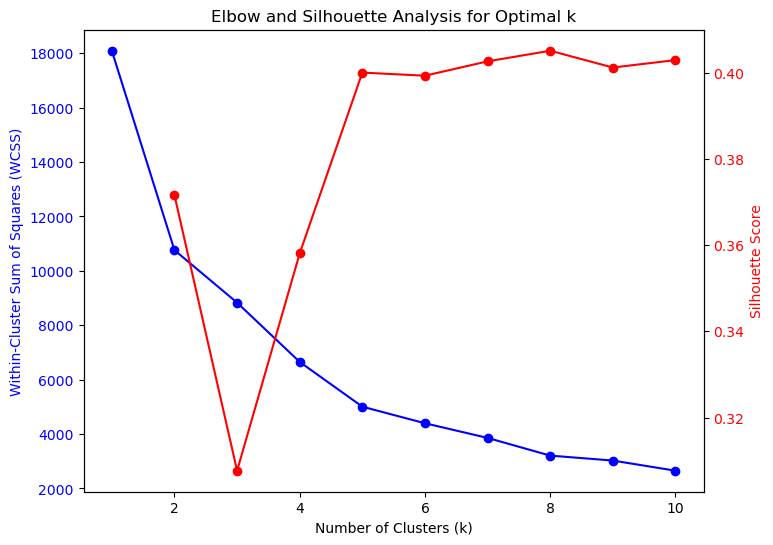

In [386]:
fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(range(1, 11), wcss, marker='o', color='blue')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')


ax2 = ax1.twinx()
ax2.plot(range(2, 11), score, marker='o', color='red')
ax2.set_ylabel('Silhouette Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.title('Elbow and Silhouette Analysis for Optimal k')

plt.show()

## 13. Clustering

Applying two clustering algorithms to the PCA-reduced data using the optimal `k` determined above, and comparing their groupings visually.

### 13.1 K-Means Clustering

**K-Means** partitions customers into `k` clusters by iteratively minimising the WCSS. It is computationally efficient and works well when clusters are roughly spherical and similarly sized.

The 3D plot below shows the cluster assignments in PCA space.

In [387]:
kmeans = KMeans(n_clusters = optimal_k, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

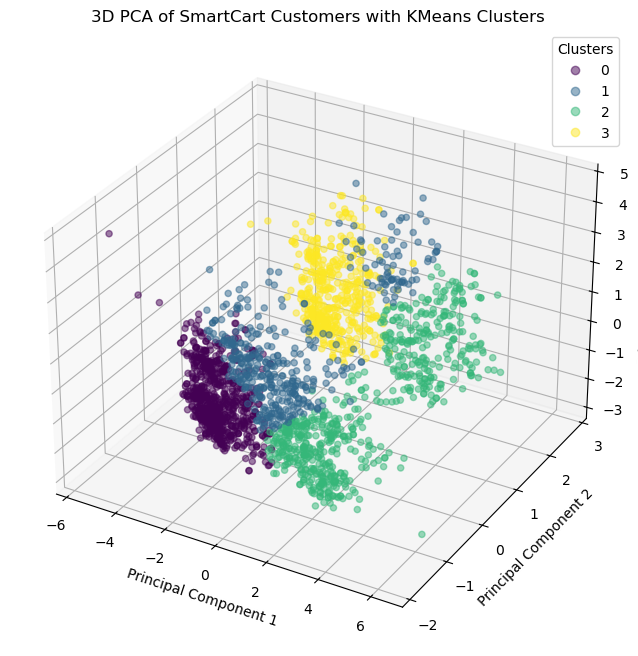

In [388]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans, cmap='viridis', alpha=0.5)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA of SmartCart Customers with KMeans Clusters')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()


### 13.2 Agglomerative Clustering

**Agglomerative (Hierarchical) Clustering** builds clusters bottom-up by merging the closest pairs of data points using **Ward linkage**, which minimises the total within-cluster variance at each merge step.

This method makes no assumptions about cluster shape and serves as a robust comparison to K-Means.

In [389]:
from sklearn.cluster import AgglomerativeClustering

In [390]:
agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
labels_agglo = agglo.fit_predict(X_pca)


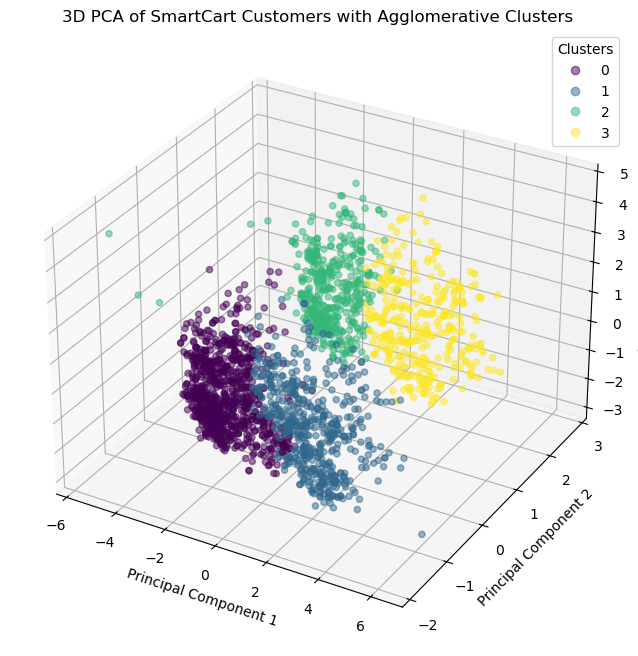

In [391]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agglo, cmap='viridis', alpha=0.5)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA of SmartCart Customers with Agglomerative Clusters')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

## 14. Cluster Profiling & Business Interpretation

Assigning the Agglomerative cluster labels back to the feature matrix and analysing the characteristics of each segment to derive actionable business insights.

In [392]:
X["labels_agglo"] = labels_agglo
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spendings,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,labels_agglo
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


### 14.1 Cluster Size Distribution

Examining how customers are distributed across clusters. Balanced cluster sizes indicate a representative segmentation, while heavily skewed sizes may warrant re-evaluation of `k`.

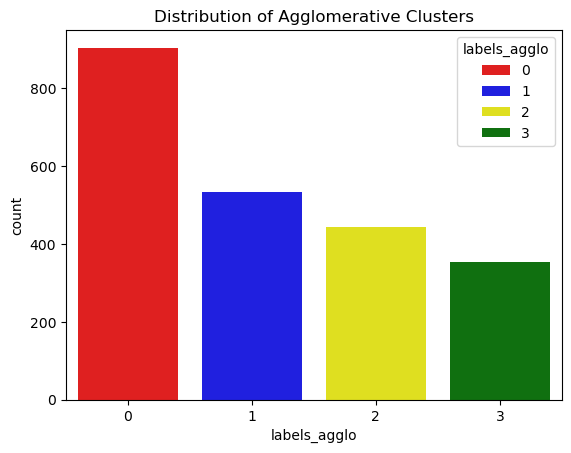

In [393]:
palettes = ['red', 'blue','yellow', 'green']
sns.countplot(x='labels_agglo', data=X, palette=palettes, hue='labels_agglo') 
plt.title('Distribution of Agglomerative Clusters')
plt.show()

### 14.2 Income vs. Total Spending by Cluster

Mapping clusters along the two most strategically important axes — **income** and **spending** — to identify high-value customers, deal-seekers, and at-risk/low-engagement segments.

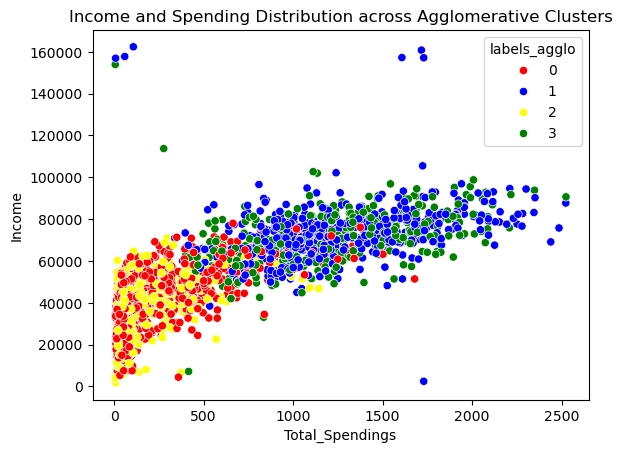

In [394]:
sns.scatterplot(x='Total_Spendings', y='Income', hue='labels_agglo', data=X, palette=palettes)
plt.title('Income and Spending Distribution across Agglomerative Clusters')
plt.show()

### 14.3 Cluster Summary Statistics

Computing the mean of all features per cluster to build a full statistical profile of each customer segment. These profiles form the basis for targeted marketing recommendations.

In [395]:
cluster_summary = X.groupby('labels_agglo').mean()
print(cluster_summary)


                    Income    Recency  NumDealsPurchases  NumWebPurchases  \
labels_agglo                                                                
0             39680.580110  48.914917           2.594475         3.153591   
1             72808.445693  49.202247           1.958801         5.687266   
2             36960.143018  48.319820           2.594595         2.713964   
3             70722.681303  50.504249           1.855524         5.790368   

              NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  \
labels_agglo                                                              
0                        0.969061           4.143646           6.307182   
1                        5.498127           8.659176           3.580524   
2                        0.837838           3.623874           6.659910   
3                        5.014164           8.430595           3.728045   

              Complain  Response        Age  Customer_Tenure_Days  \
labels_agglo     

## 15. Conclusion & Business Insights

The Agglomerative Clustering model identified **4 distinct customer segments** within SmartCart's 2,240-customer base. Each cluster tells a clear behavioural story with direct marketing implications.

---

### Cluster Profiles at a Glance

| Metric | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 |
|---|---|---|---|---|
| **Segment Name** | Budget Families | Affluent Families | Struggling Singles | High-Value Singles |
| **Avg. Income** | £39,681 | £72,808 | £36,960 | £70,723 |
| **Avg. Total Spend** | £222 | £1,237 | £166 | £1,190 |
| **Living With** | Partner (100%) | Partner (100%) | Alone (99%) | Alone (100%) |
| **Avg. Children** | 1.24 | 0.51 | 1.27 | 0.46 |
| **Campaign Response Rate** | 7.6% | 16.7% | 14.2% | **32.0%** |
| **Web Visits / Month** | 6.3 | 3.6 | **6.7** | 3.7 |
| **Store Purchases** | 4.1 | **8.7** | 3.6 | 8.4 |

---

### Cluster 0 — Budget Families 👨‍👩‍👧
- **Profile:** Mid-low income couples with children (~1.24 kids). Moderate web visitors but low converters. Low spend (£222) and lowest campaign response rate (7.6%).
- **Business Action:** Target with **family bundle deals**, child-related product promotions, and discount-led campaigns. They visit the site frequently — the barrier is price, not awareness.

---

### Cluster 1 — Affluent Families 💳
- **Profile:** High-income (£72,808) couples with few children. Heavy multi-channel shoppers — high store, web, and catalogue purchases. Spend 5× more than Cluster 0.
- **Business Action:** Invest in **premium loyalty programmes**, personalised cross-sell recommendations, and exclusive early-access offers. Do not waste margins on discounts — this segment buys at full price.

---

### Cluster 2 — Struggling Singles ⚠️
- **Profile:** Lowest income (£36,960) and lowest spend (£166) of all clusters. Living alone, often with children (~1.27 — likely single parents). Highest web visit frequency (6.7/month) yet lowest purchase conversion.
- **Business Action:** High engagement but financial constraint is the bottleneck. Target with **time-limited discount codes**, instalment/BNPL promotions, and affordable entry-level product recommendations to convert browsing into purchases.

---

### Cluster 3 — High-Value Singles 🌟
- **Profile:** High-income (£70,723) individuals living alone, childless, and longest-tenured customers (376 days). The **most campaign-responsive segment** at 32% — 4× the rate of Cluster 0. Heavy catalogue and store shoppers.
- **Business Action:** The highest-priority segment for personalised outreach. Deploy **targeted email and catalogue campaigns** knowing conversion rates are high. Introduce a VIP or concierge tier to deepen retention and lifetime value.

---

### Key Takeaways

- **Income and family structure** are the two primary axes separating all four segments
- **Campaign responsiveness varies dramatically** — Cluster 3 (32%) vs Cluster 0 (7.6%) — meaning a one-size-fits-all marketing approach wastes ~92% of spend on the wrong audience
- **High web visits ≠ high spend** (Cluster 2 visits most, spends least) — visit frequency alone is a misleading success metric without conversion context
- Segmenting customers this way allows SmartCart to shift from **generic blasts** to **four distinct, data-driven communication strategies** — directly addressing the original problem statement